# Exploration des données — Football AI Predictor

**Plan :**
1. Chargement et apercu general
2. Distribution des resultats (avantage du domicile)
3. Distribution des buts (verification Poisson)
4. Evolution par saison
5. Analyse par equipe
6. Correlations entre variables
7. Importance des features
8. Comprendre la prediction PSG vs Marseille
9. Synthese

In [15]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [16]:
-m pip install --upgrade pip


SyntaxError: invalid syntax (294659197.py, line 1)

In [18]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


## 0. Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import poisson
import joblib
import sys
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {'dom': '#2E86C1', 'ext': '#E74C3C', 'nul': '#95A5A6', 'accent': '#27AE60'}

print('Setup OK')

Setup OK


## 1. Chargement et apercu general

In [20]:
df = pd.read_csv('../data/processed/ligue1_clean.csv', parse_dates=['date'])

print(f'Matchs        : {len(df)}')
print(f'Colonnes      : {df.shape[1]}')
print(f'Periode       : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Saisons       : {sorted(df["season"].unique())}')
print(f'Equipes       : {df["home_team"].nunique()}')
df.head(8)

Matchs        : 1725
Colonnes      : 20
Periode       : 2019-08-09 -> 2024-05-19
Saisons       : [1920, 2021, 2122, 2223, 2324]
Equipes       : 27


,date,home_team,away_team,home_goals,away_goals,result,home_shots,away_shots,home_shots_target,away_shots_target,home_corners,away_corners,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,season,target
0,2019-08-09,Monaco,Lyon,0,3,A,7,13,1,3,2,5,10,17,2,2,1,0,1920,0
1,2019-08-10,Marseille,Reims,0,2,A,10,8,2,5,5,3,18,8,1,0,0,0,1920,0
2,2019-08-10,Angers,Bordeaux,3,1,H,14,8,4,3,4,3,11,15,2,1,0,0,1920,2
3,2019-08-10,Brest,Toulouse,1,1,D,16,13,5,3,4,7,11,14,0,0,0,0,1920,1
4,2019-08-10,Dijon,St Etienne,1,2,A,15,12,7,4,12,5,17,10,0,2,0,0,1920,0
5,2019-08-10,Montpellier,Rennes,0,1,A,24,9,5,3,7,1,20,19,3,3,0,1,1920,0
6,2019-08-10,Nice,Amiens,2,1,H,17,8,6,2,7,3,10,8,3,4,0,1,1920,2
7,2019-08-11,Lille,Nantes,2,1,H,13,13,3,3,5,11,13,17,2,4,0,0,1920,2


In [21]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('Aucune valeur manquante sur les colonnes cles')
else:
    print('Valeurs manquantes detectees :')
    print(missing)
print()
print(df.dtypes)

Aucune valeur manquante sur les colonnes cles

date                 datetime64[ns]
home_team                    object
away_team                    object
home_goals                    int64
away_goals                    int64
result                       object
home_shots                    int64
away_shots                    int64
home_shots_target             int64
away_shots_target             int64
home_corners                  int64
away_corners                  int64
home_fouls                    int64
away_fouls                    int64
home_yellow                   int64
away_yellow                   int64
home_red                      int64
away_red                      int64
season                        int64
target                        int64
dtype: object


## 2. Distribution des resultats

C'est la **baseline naive** : un modele qui predit toujours l'issue la plus frequente atteint cette precision sans rien apprendre. Notre modele doit faire mieux.

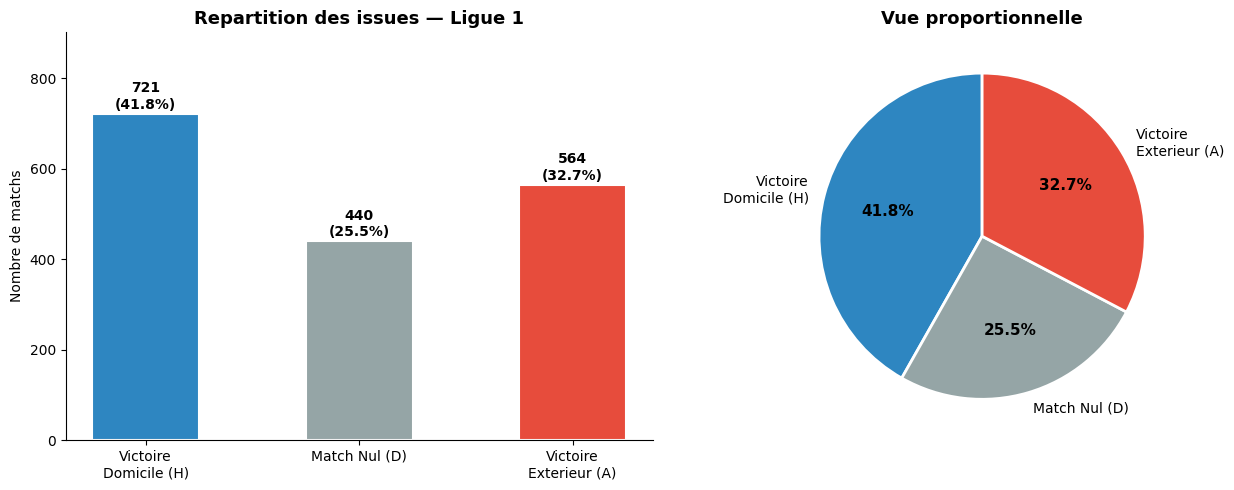

Baseline naive : 41.8%
Notre modele doit depasser ce seuil pour avoir une valeur ajoutee.


In [22]:
result_counts = df['result'].value_counts()
result_pct = df['result'].value_counts(normalize=True).round(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barres
labels = ['Victoire\nDomicile (H)', 'Match Nul (D)', 'Victoire\nExterieur (A)']
values = [result_counts.get('H', 0), result_counts.get('D', 0), result_counts.get('A', 0)]
colors = [COLORS['dom'], COLORS['nul'], COLORS['ext']]
bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

pcts = [result_pct.get('H', 0), result_pct.get('D', 0), result_pct.get('A', 0)]
for bar, val, pct in zip(bars, values, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({pct:.1%})', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Repartition des issues — Ligue 1', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de matchs')
axes[0].set_ylim(0, max(values) * 1.25)

# Pie
wedges, texts, autotexts = axes[1].pie(
    values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Vue proportionnelle', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/plot_results.png', dpi=150, bbox_inches='tight')
plt.show()

baseline = max(pcts)
print(f'Baseline naive : {baseline:.1%}')
print(f'Notre modele doit depasser ce seuil pour avoir une valeur ajoutee.')

## 3. Distribution des buts — verification de la Loi de Poisson

Les barres bleues = donnees reelles. Les barres orange = Poisson theorique.  
Si elles se superposent bien, Poisson est un bon modele pour ces donnees.

Equipe Domicile — lambda = 1.483 buts/match
Equipe Exterieur — lambda = 1.249 buts/match


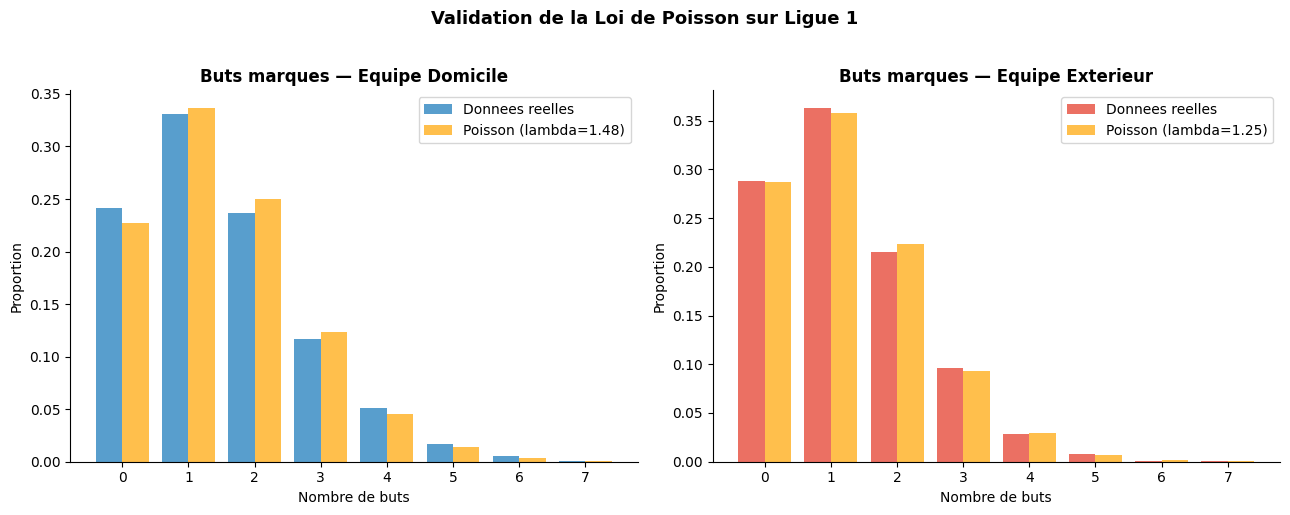

Si les barres se superposent -> Poisson est valide.
Les ecarts residuels sont les non-linearites que XGBoost apprend automatiquement.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label, color in [
    (axes[0], 'home_goals', 'Equipe Domicile', COLORS['dom']),
    (axes[1], 'away_goals', 'Equipe Exterieur', COLORS['ext'])
]:
    lam = df[col].mean()
    buts = np.arange(0, 8)

    real_counts = df[col].value_counts(normalize=True).reindex(buts, fill_value=0)
    ax.bar([b - 0.2 for b in buts], real_counts.values,
           width=0.4, color=color, alpha=0.8, label='Donnees reelles')

    poisson_proba = poisson.pmf(buts, lam)
    ax.bar([b + 0.2 for b in buts], poisson_proba,
           width=0.4, color='orange', alpha=0.7, label=f'Poisson (lambda={lam:.2f})')

    ax.set_title(f'Buts marques — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nombre de buts')
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=10)
    ax.set_xticks(buts)
    print(f'{label} — lambda = {lam:.3f} buts/match')

plt.suptitle('Validation de la Loi de Poisson sur Ligue 1',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/plot_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

print('Si les barres se superposent -> Poisson est valide.')
print('Les ecarts residuels sont les non-linearites que XGBoost apprend automatiquement.')

## 4. Evolution par saison

=== Stats par saison ===
        buts_dom  buts_ext  pct_H  pct_D  pct_A
season                                         
1920       1.495     1.029  0.480  0.251  0.269
2021       1.397     1.363  0.374  0.250  0.376
2122       1.582     1.226  0.426  0.268  0.305
2223       1.489     1.318  0.429  0.242  0.329
2324       1.448     1.252  0.392  0.265  0.343


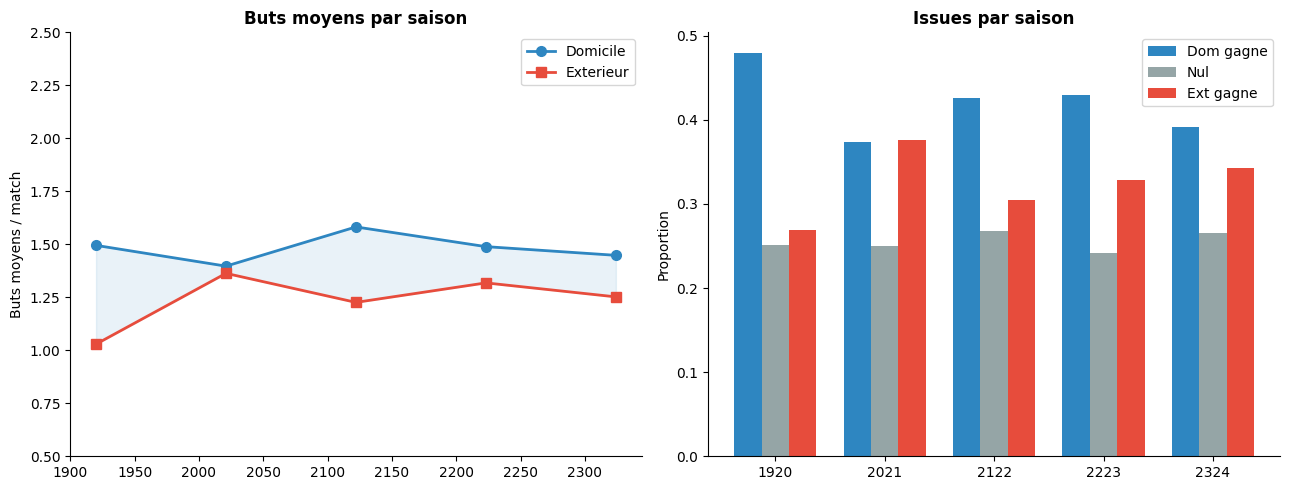

In [24]:
season_stats = df.groupby('season').agg(
    buts_dom=('home_goals', 'mean'),
    buts_ext=('away_goals', 'mean'),
    pct_H=('result', lambda x: (x == 'H').mean()),
    pct_D=('result', lambda x: (x == 'D').mean()),
    pct_A=('result', lambda x: (x == 'A').mean()),
).round(3)

print('=== Stats par saison ===')
print(season_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
seasons = season_stats.index

# Buts
axes[0].plot(seasons, season_stats['buts_dom'], 'o-',
             color=COLORS['dom'], lw=2, ms=7, label='Domicile')
axes[0].plot(seasons, season_stats['buts_ext'], 's-',
             color=COLORS['ext'], lw=2, ms=7, label='Exterieur')
axes[0].fill_between(seasons, season_stats['buts_dom'],
                      season_stats['buts_ext'], alpha=0.1, color=COLORS['dom'])
axes[0].set_title('Buts moyens par saison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Buts moyens / match')
axes[0].legend()
axes[0].set_ylim(0.5, 2.5)

# Issues
x = np.arange(len(seasons))
w = 0.25
axes[1].bar(x - w, season_stats['pct_H'], w, color=COLORS['dom'], label='Dom gagne')
axes[1].bar(x,     season_stats['pct_D'], w, color=COLORS['nul'], label='Nul')
axes[1].bar(x + w, season_stats['pct_A'], w, color=COLORS['ext'], label='Ext gagne')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seasons)
axes[1].set_title('Issues par saison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/plot_seasons.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse par equipe

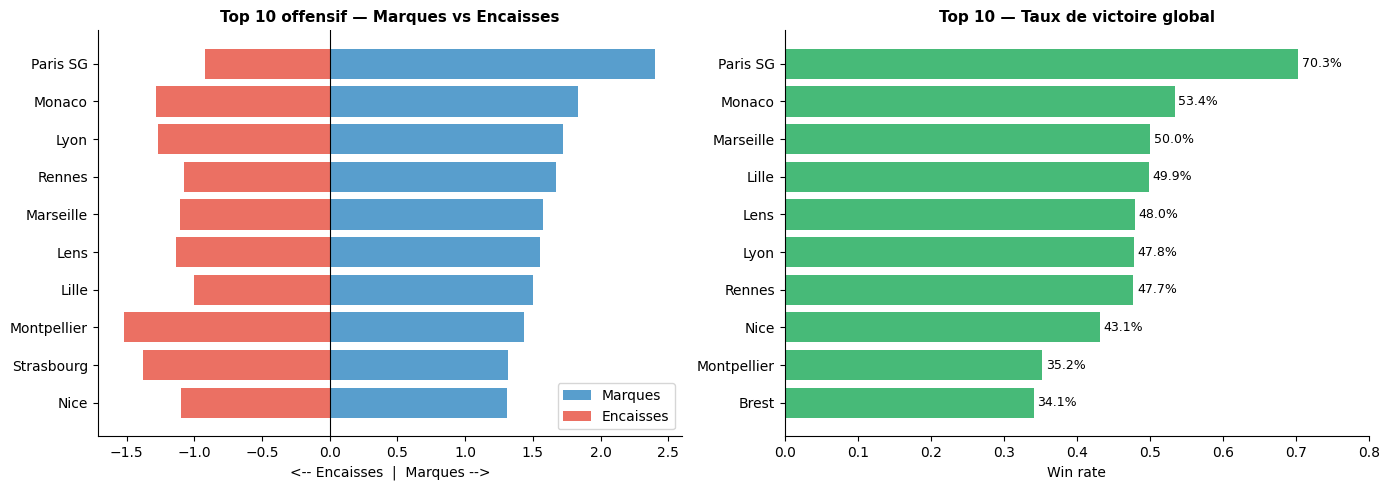

=== Noms exacts des equipes dans les donnees ===
  Ajaccio
  Amiens
  Angers
  Auxerre
  Bordeaux
  Brest
  Clermont
  Dijon
  Le Havre
  Lens
  Lille
  Lorient
  Lyon
  Marseille
  Metz
  Monaco
  Montpellier
  Nantes
  Nice
  Nimes
  Paris SG
  Reims
  Rennes
  St Etienne
  Strasbourg
  Toulouse
  Troyes


In [25]:
home_s = df.groupby('home_team').agg(
    buts_m_dom=('home_goals', 'mean'),
    buts_e_dom=('away_goals', 'mean'),
    win_dom=('result', lambda x: (x == 'H').mean())
)
away_s = df.groupby('away_team').agg(
    buts_m_ext=('away_goals', 'mean'),
    buts_e_ext=('home_goals', 'mean'),
    win_ext=('result', lambda x: (x == 'A').mean())
)
team_stats = home_s.join(away_s, how='inner')
team_stats['buts_moy'] = (team_stats['buts_m_dom'] + team_stats['buts_m_ext']) / 2
team_stats['buts_enc'] = (team_stats['buts_e_dom'] + team_stats['buts_e_ext']) / 2
team_stats['win_rate'] = (team_stats['win_dom'] + team_stats['win_ext']) / 2

top10 = team_stats.nlargest(10, 'buts_moy')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buts marques vs encaisses
axes[0].barh(top10.index[::-1], top10['buts_moy'][::-1],
             color=COLORS['dom'], alpha=0.8, label='Marques')
axes[0].barh(top10.index[::-1], -top10['buts_enc'][::-1],
             color=COLORS['ext'], alpha=0.8, label='Encaisses')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Top 10 offensif — Marques vs Encaisses', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('<-- Encaisses  |  Marques -->')

# Win rate
top_win = team_stats.nlargest(10, 'win_rate')
bars = axes[1].barh(top_win.index[::-1], top_win['win_rate'][::-1],
                    color=COLORS['accent'], alpha=0.85)
for bar, val in zip(bars, top_win['win_rate'][::-1]):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)
axes[1].set_title('Top 10 — Taux de victoire global', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Win rate')
axes[1].set_xlim(0, 0.8)

plt.tight_layout()
plt.savefig('../data/processed/plot_teams.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats PSG et Marseille
print('=== Noms exacts des equipes dans les donnees ===')
for t in sorted(df['home_team'].unique()):
    print(f'  {t}')

## 6. Matrice de correlations

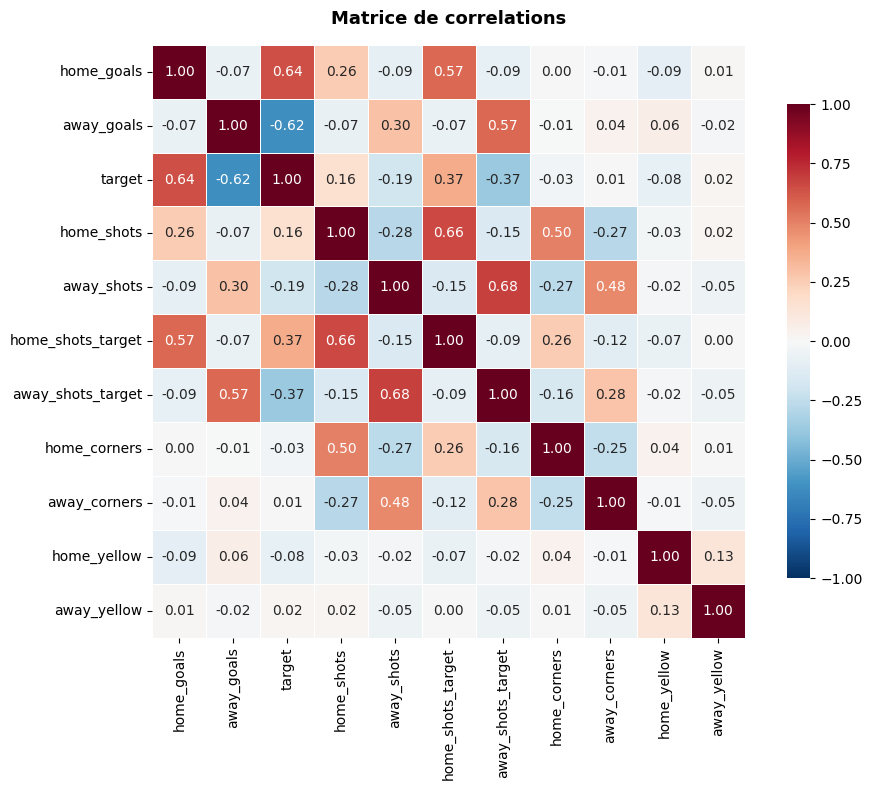

=== Correlation avec la variable cible (target) ===
(+1 = lie a victoire domicile, -1 = lie a victoire exterieur)

  home_goals                +0.642  XXXXXXXXXXXX
  home_shots_target         +0.372  XXXXXXX
  home_shots                +0.162  XXX
  away_yellow               +0.020  
  away_corners              +0.008  
  home_corners              -0.035  
  home_yellow               -0.079  X
  away_shots                -0.195  XXX
  away_shots_target         -0.373  XXXXXXX
  away_goals                -0.624  XXXXXXXXXXXX


In [26]:
num_cols = ['home_goals', 'away_goals', 'target',
            'home_shots', 'away_shots',
            'home_shots_target', 'away_shots_target',
            'home_corners', 'away_corners',
            'home_yellow', 'away_yellow']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de correlations', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/plot_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Correlation avec la variable cible (target) ===')
print('(+1 = lie a victoire domicile, -1 = lie a victoire exterieur)')
print()
target_corr = corr['target'].drop('target').sort_values(ascending=False)
for var, val in target_corr.items():
    bar = 'X' * int(abs(val) * 20)
    sign = '+' if val >= 0 else '-'
    print(f'  {var:<25} {sign}{abs(val):.3f}  {bar}')

## 7. Importance des features — ce que XGBoost a vraiment appris

In [28]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


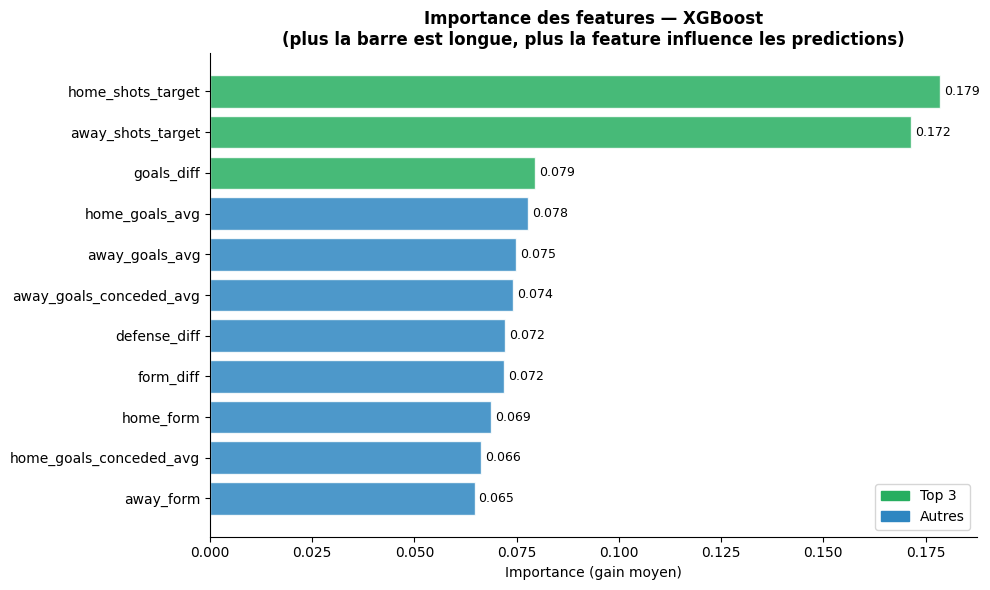

=== Top 3 features les plus importantes ===
  * home_shots_target  ->  0.179
  * away_shots_target  ->  0.172
  * goals_diff  ->  0.079

Ces 3 features expliquent la majorite des predictions.
C'est la qu'on doit concentrer l'effort d'amelioration.


In [29]:
model_path = '../models/xgb_model.pkl'

if not os.path.exists(model_path):
    print('Modele non trouve. Lance : python src/model.py')
else:
    model = joblib.load(model_path)

    feature_names = [
        'home_goals_avg', 'away_goals_avg',
        'home_goals_conceded_avg', 'away_goals_conceded_avg',
        'home_form', 'away_form',
        'goals_diff', 'defense_diff', 'form_diff',
        'home_shots_target', 'away_shots_target',
    ]

    importance = model.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    imp_df = imp_df.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    n = len(imp_df)
    colors_bar = [COLORS['accent'] if i >= n - 3 else COLORS['dom'] for i in range(n)]
    bars = ax.barh(imp_df['feature'], imp_df['importance'],
                   color=colors_bar, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, imp_df['importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_title('Importance des features — XGBoost\n(plus la barre est longue, plus la feature influence les predictions)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance (gain moyen)')

    green_p = mpatches.Patch(color=COLORS['accent'], label='Top 3')
    blue_p  = mpatches.Patch(color=COLORS['dom'],    label='Autres')
    ax.legend(handles=[green_p, blue_p])

    plt.tight_layout()
    plt.savefig('../data/processed/plot_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Top 3 features les plus importantes ===')
    top3 = imp_df.nlargest(3, 'importance')
    for _, row in top3.iterrows():
        print(f'  * {row["feature"]}  ->  {row["importance"]:.3f}')
    print()
    print('Ces 3 features expliquent la majorite des predictions.')
    print("C'est la qu'on doit concentrer l'effort d'amelioration.")

## 8. Comprendre la prediction PSG vs Marseille

On reproduit manuellement le calcul du modele pour comprendre le resultat obtenu.

In [30]:
sys.path.insert(0, '../src')
from feature_engineering import get_team_stats_before

# Verifie d'abord les noms exacts dans la cellule precedente
# puis ajuste HOME_TEAM et AWAY_TEAM si necessaire
HOME_TEAM = 'Paris SG'
AWAY_TEAM = 'Marseille'

date_pred = pd.Timestamp('2026-01-01')

home_stats = get_team_stats_before(df, HOME_TEAM, date_pred, 'home')
away_stats = get_team_stats_before(df, AWAY_TEAM, date_pred, 'away')
all_home   = get_team_stats_before(df, HOME_TEAM, date_pred, 'both')
all_away   = get_team_stats_before(df, AWAY_TEAM, date_pred, 'both')

print(f'=== Features calculees pour {HOME_TEAM} vs {AWAY_TEAM} ===')
print()
features = {
    'home_goals_avg':          home_stats['goals_scored_mean'],
    'away_goals_avg':          away_stats['goals_scored_mean'],
    'home_goals_conceded_avg': home_stats['goals_conceded_mean'],
    'away_goals_conceded_avg': away_stats['goals_conceded_mean'],
    'home_form':               all_home['points_sum'],
    'away_form':               all_away['points_sum'],
    'goals_diff':              home_stats['goals_scored_mean'] - away_stats['goals_scored_mean'],
    'defense_diff':            away_stats['goals_conceded_mean'] - home_stats['goals_conceded_mean'],
    'form_diff':               all_home['points_sum'] - all_away['points_sum'],
}
for k, v in features.items():
    print(f'  {k:<30} {v:.3f}')

print()
print(f'goals_diff = {features["goals_diff"]:.3f}')
print('  -> Si proche de 0 : le modele ne voit pas de grand favori')
print(f'form_diff  = {features["form_diff"]:.3f}')
print('  -> Differentiel de forme recente')
print()
print('Explication : les donnees historiques moyennes de PSG dom et Marseille ext')
print("sont proches car il manque la feature 'classement_diff'. C'est le probleme")
print("qu'on va corriger dans la Phase 2.")

=== Features calculees pour Paris SG vs Marseille ===

  home_goals_avg                 2.200
  away_goals_avg                 1.500
  home_goals_conceded_avg        1.600
  away_goals_conceded_avg        1.500
  home_form                      10.000
  away_form                      7.000
  goals_diff                     0.700
  defense_diff                   -0.100
  form_diff                      3.000

goals_diff = 0.700
  -> Si proche de 0 : le modele ne voit pas de grand favori
form_diff  = 3.000
  -> Differentiel de forme recente

Explication : les donnees historiques moyennes de PSG dom et Marseille ext
sont proches car il manque la feature 'classement_diff'. C'est le probleme
qu'on va corriger dans la Phase 2.


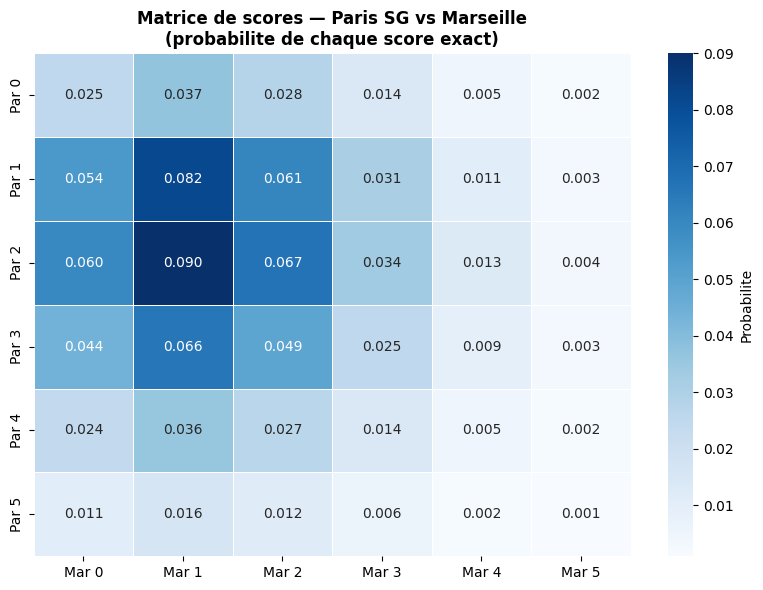

=== Probabilites Poisson pur (sans ML) ===
  Victoire Paris SG : 51.1%
  Match nul           : 20.4%
  Victoire Marseille : 25.6%

Compare avec ce que XGBoost a predit.
Les ecarts montrent ce que le ML ajoute par rapport au modele Poisson.


In [31]:
# Matrice de scores Poisson
lambda_home = home_stats['goals_scored_mean']
lambda_away = away_stats['goals_scored_mean']

buts = np.arange(0, 6)
matrice = np.outer(poisson.pmf(buts, lambda_home), poisson.pmf(buts, lambda_away))
df_mat = pd.DataFrame(
    matrice.round(3),
    index=[f'{HOME_TEAM[:3]} {i}' for i in buts],
    columns=[f'{AWAY_TEAM[:3]} {i}' for i in buts]
)

plt.figure(figsize=(8, 6))
sns.heatmap(df_mat, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Probabilite'})
plt.title(f'Matrice de scores — {HOME_TEAM} vs {AWAY_TEAM}\n(probabilite de chaque score exact)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot_score_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

prob_dom = matrice[np.tril_indices(6, k=-1)].sum()
prob_nul = np.trace(matrice)
prob_ext = matrice[np.triu_indices(6, k=1)].sum()

print(f'=== Probabilites Poisson pur (sans ML) ===')
print(f'  Victoire {HOME_TEAM} : {prob_dom:.1%}')
print(f'  Match nul           : {prob_nul:.1%}')
print(f'  Victoire {AWAY_TEAM} : {prob_ext:.1%}')
print()
print('Compare avec ce que XGBoost a predit.')
print("Les ecarts montrent ce que le ML ajoute par rapport au modele Poisson.")

## 9. Synthese finale

In [32]:
baseline = df['result'].value_counts(normalize=True).max()
lam_h = df['home_goals'].mean()
lam_a = df['away_goals'].mean()

print('=' * 56)
print('  SYNTHESE DE LEXPLORATION')
print('=' * 56)
print(f"""
Ce qu'on a confirme :
  Baseline naive           : {baseline:.1%}
  Lambda domicile (Poisson): {lam_h:.3f} buts/match
  Lambda exterieur         : {lam_a:.3f} buts/match
  Avantage domicile reel   : {lam_h - lam_a:+.3f} buts/match
  Poisson est valide empiriquement sur ces donnees

Ce qui explique PSG a 7.5% :
  goals_diff ~ 0  -> le modele ne voit pas d'ecart offensif
  Il manque la feature 'classement_diff'
  Seulement 5 saisons de donnees

Prochaines ameliorations (ordre de priorite) :
  1. Ajouter classement_diff      -> +2-3% accuracy
  2. Ajouter ratio attaque/defense croise
  3. Ponderation temporelle (matchs recents > anciens)
  4. Donnees h2h (confrontations directes)
  5. Etendre a 10 saisons
""")
print('=' * 56)

  SYNTHESE DE LEXPLORATION

Ce qu'on a confirme :
  Baseline naive           : 41.8%
  Lambda domicile (Poisson): 1.483 buts/match
  Lambda exterieur         : 1.249 buts/match
  Avantage domicile reel   : +0.234 buts/match
  Poisson est valide empiriquement sur ces donnees

Ce qui explique PSG a 7.5% :
  goals_diff ~ 0  -> le modele ne voit pas d'ecart offensif
  Il manque la feature 'classement_diff'
  Seulement 5 saisons de donnees

Prochaines ameliorations (ordre de priorite) :
  1. Ajouter classement_diff      -> +2-3% accuracy
  2. Ajouter ratio attaque/defense croise
  3. Ponderation temporelle (matchs recents > anciens)
  4. Donnees h2h (confrontations directes)
  5. Etendre a 10 saisons

